In [1]:
import pandas as pd
import numpy as np
from os import listdir
import os
import matplotlib.pyplot as plt

In [2]:
def csv_df(mypath, columns):
    mean = pd.read_csv(mypath + '2024-02-04.csv')
    mean['mean'] = mean[columns].mean(axis=1)
    mean.sort_values(by=['mean'], inplace=True, ascending=False)
    mean = mean[['Unnamed: 0', 'mean']].rename(columns={'mean': '2024-02-04'})
    
    for f in os.listdir(mypath)[2:]:
        meanf = pd.read_csv(mypath + f)
        meanf['mean'] = meanf[columns].mean(axis=1)
        meanf = meanf[['Unnamed: 0', 'mean']].rename(columns={'mean': f[:-4]})
        mean = pd.merge(mean, meanf, how='left', on='Unnamed: 0')
    
    mean = mean.T
    mean = mean.rename(columns=mean.loc['Unnamed: 0'])
    mean.drop('Unnamed: 0', axis=0, inplace=True)
    return mean

In [ ]:
#['noExperience', 'between1And3', 'between3And6','moreThan6']

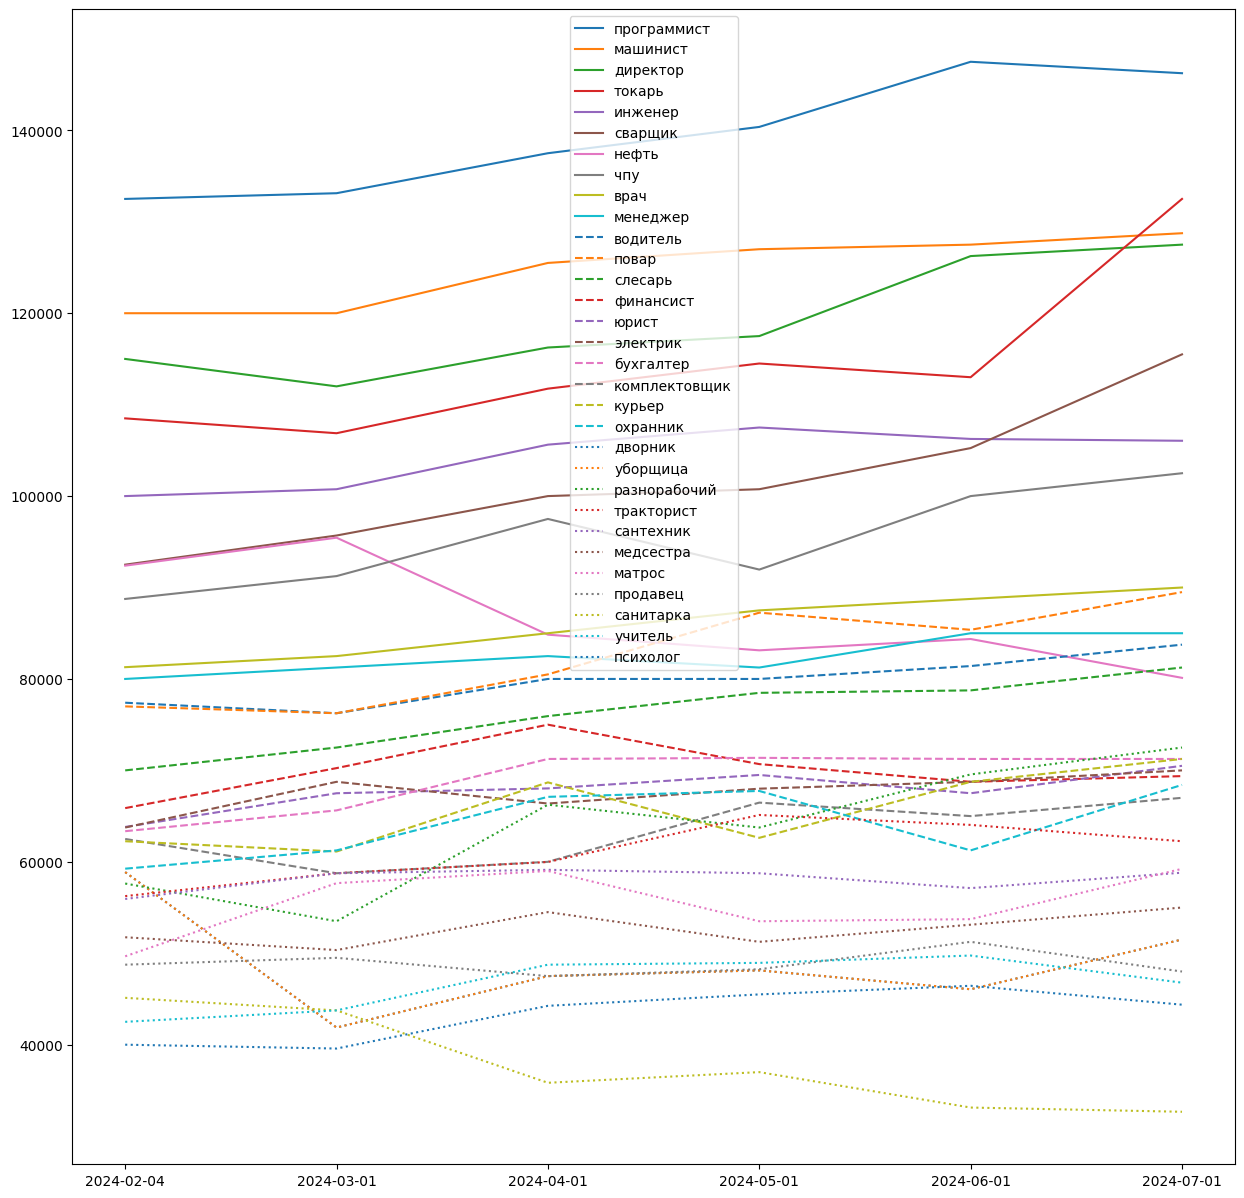

In [3]:
mean1 = csv_df('./profs/', ['noExperience', 'between1And3', 'between3And6','moreThan6']).copy()
colmns = mean1.columns

fig, ax = plt.subplots()
fig.set_size_inches(15, 15)
labels = []

for i in enumerate(colmns):
    if i[0] < 10:
        ax.plot(mean1[i[1]])
        labels.append(mean1[i[1]].name)
        col = i
    elif 20> i[0] >= 10:
        ax.plot(mean1[i[1]], linestyle='--')
        labels.append(mean1[i[1]].name)
    elif i[0] >= 20:
        ax.plot(mean1[i[1]], linestyle=':')
        labels.append(mean1[i[1]].name)

ax.legend(labels)

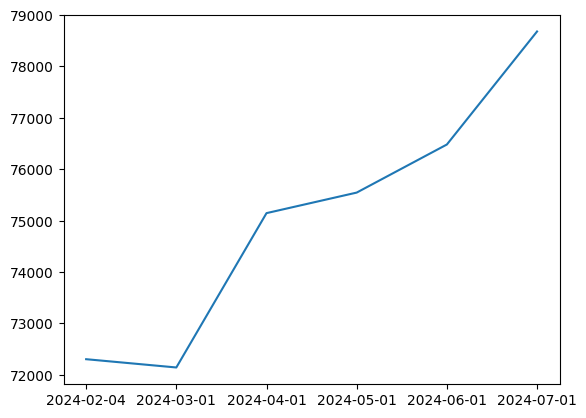

In [4]:
plt.plot(mean1.mean(axis=1))

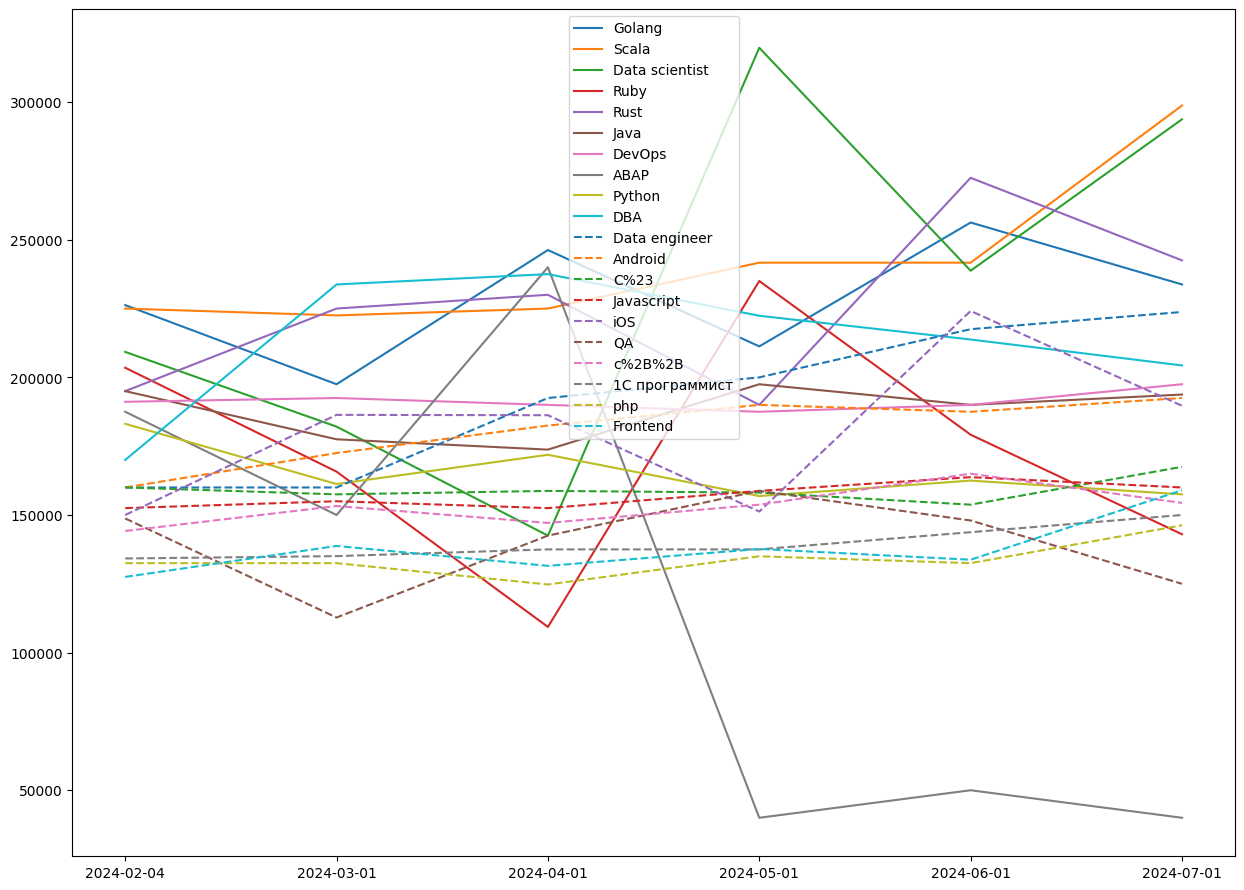

In [5]:
mean1 = csv_df('./langs/', ['noExperience', 'between1And3', 'between3And6','moreThan6']).copy()
colmns = mean1.columns

fig, ax = plt.subplots()
fig.set_size_inches(15, 11)
labels = []
col = ""

for i in colmns:
    if col[:2] != 'DB':
        ax.plot(mean1[i])
        labels.append(mean1[i].name)
        col = i
    else:
        ax.plot(mean1[i], linestyle='--')
        labels.append(mean1[i].name)
        col = 'DB'

ax.legend(labels)

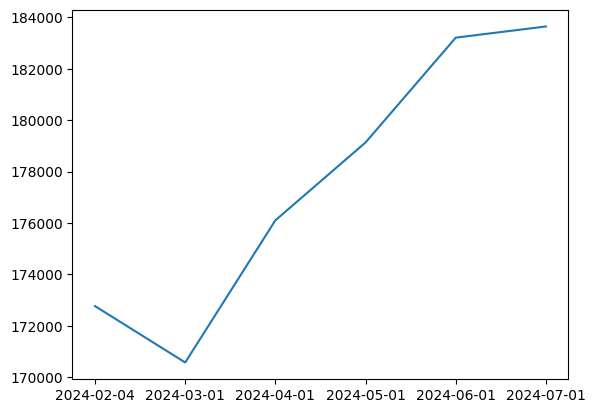

In [6]:
plt.plot(mean1.mean(axis=1))